# DPO: Direct Preference Optimization — 실습 코드 2: DPO Loss 직접 구현 (PyTorch)

- Tutorial ID: `expand-dpo`
- Tutorial: DPO: Direct Preference Optimization
- Section ID: `expand-dpo-code-2`
- Section: 실습 코드 2: DPO Loss 직접 구현 (PyTorch)

> 이 노트북은 원래 실습 코드의 문법 오류를 고치고, **처음 DPO를 공부하는 분**이 수식 → 코드 → 실행 결과까지 끊김 없이 따라올 수 있도록 설명과 예제를 대폭 보강한 버전입니다.

## 이 노트북에서 배우는 것

1. DPO 손실 함수가 어떤 아이디어에서 나왔는지, 쉬운 비유로 먼저 감을 잡습니다.
2. 수식의 각 기호($\pi_\theta$, $\pi_{ref}$, $\beta$, $y_w$, $y_l$)가 코드의 어떤 변수와 대응하는지 하나씩 연결합니다.
3. `DPOLoss` 클래스를 **손 계산 → 코드 구현 → 검증** 순서로 직접 만듭니다.
4. 실제 언어모델에서 "로그 확률"을 어떻게 뽑아내는지 이해하고, 아주 작은 토이(toy) 모델로 **직접 실행되는** DPO 학습 파이프라인을 끝까지 돌려봅니다.
5. 마지막으로 DPO와 RLHF(PPO)를 여러 기준으로 비교합니다.

> 💻 이 노트북은 `torch`, `matplotlib`만으로 실행됩니다. 별도의 GPU나 사전학습 모델 다운로드가 필요 없습니다. 위에서부터 순서대로 실행(Run All)하면서 따라가 주세요.

In [1]:
# ============================================================
# 코드 읽는 법 — 실습 코드 2: DPO Loss 직접 구현 (PyTorch)
#
# 이 코드는 "정답을 한 번 실행"하는 용도가 아니라,
# 수학 수식이 실제 텐서 연산으로 바뀌는 과정을 한 줄씩 추적하기 위한 실험 노트입니다.
#
# 학습 목표:
#   1) 선호쌍(chosen/rejected)이 어떻게 하나의 loss 값으로 바뀌는지 확인
#   2) 그 loss가 policy 모델의 파라미터를 어떻게 업데이트하는지 확인
#
# 읽는 순서:
#   1) 하이퍼파라미터(beta, learning rate, epoch 수)를 먼저 확인합니다.
#   2) chosen/rejected 문장이 어떻게 숫자(토큰 id)로 바뀌는지 봅니다.
#   3) 모델이 각 토큰에 대해 내놓는 "로그 확률"이 어디서, 어떻게 계산되는지 확인합니다.
#   4) logratio -> logits -> loss로 이어지는 핵심 연산 직후의 shape와 값을 출력으로 검증합니다.
#   5) beta, learning rate, loss_type("sigmoid" vs "hinge") 등을 바꿔보면서
#      결과(loss, accuracy, margin)가 어떻게 달라지는지 실험해 보세요.
#
# 주의:
#   - 숫자 하나하나를 외우기보다 "값이 왜 이렇게 움직이는지"를 보세요.
#   - 파이썬은 들여쓰기(indentation)로 코드 블록을 구분합니다. 같은 함수/클래스 안의
#     코드는 반드시 같은 들여쓰기 폭을 유지해야 하며, 한 칸이라도 어긋나면
#     IndentationError가 나거나 코드가 전혀 다른 의미로 실행됩니다.
# ============================================================

## 0. 시작하기 전에 — DPO를 한 문장으로

**DPO는 "이 답변이 저 답변보다 낫다"는 상대 비교 정보만으로, 언어모델을 직접 학습시키는 방법입니다.**

비유를 하나 들어보겠습니다.

> 요리 경연 대회에서 심사위원이 "이 요리는 87.3점, 저 요리는 82.1점"처럼 정확한 점수를 매기지 않고
> 그냥 **"A가 B보다 낫다"**라고만 말해줘도, 요리사는 그 비교 피드백만으로 다음 요리를 개선할 수 있습니다.
> DPO는 언어모델에게 바로 이런 식으로, "A 답변이 B 답변보다 낫다"는 사람의 선호 데이터만 주고 학습시키는 방법입니다.

기존 RLHF(PPO 기반) 방식과 비교하면 이렇게 됩니다.

| | 1단계 | 2단계 | 3단계 |
|---|---|---|---|
| **RLHF (PPO)** | SFT (지도학습으로 기본기 다지기) | **Reward Model** 학습 (점수를 매기는 별도 모델을 만듦) | **PPO**로 정책을 강화학습 (상대적으로 불안정하고 무거움) |
| **DPO** | SFT | **DPO로 정책을 직접 최적화** (Reward Model도, 강화학습 루프도 필요 없음) | — |

DPO 논문(Rafailov et al., 2023)의 핵심 통찰은, "Reward Model을 명시적으로 학습시키지 않아도, 그 Reward Model이 있었다면 나왔을 최적 정책의 수식을 미리 풀어두면, 결국 policy 모델 자체의 로그 확률만으로 그 보상을 대신 표현할 수 있다"는 것입니다. 이 부분은 2장에서 다시 다룹니다.

이 노트북의 흐름은 다음과 같습니다.

```
수식 뜯어보기 → 손으로 계산 → 클래스로 구현 → 배치로 확장
→ 실제 모델에서 로그확률 뽑는 법 → 초소형 토이 모델로 학습 전체 파이프라인 실행 → RLHF와 비교
```

## 1. 용어 정리 — 앞으로 계속 나올 기호들

수식과 코드에 반복해서 등장하는 기호를 미리 표로 정리합니다. 낯선 기호가 나올 때마다 이 표로 돌아와 확인하세요.

| 기호 | 의미 | 코드 변수명 |
|---|---|---|
| $x$ | 프롬프트 (입력 질문) | `prompt` |
| $y_w$ | **chosen** — 사람이 더 선호한 답변 (w = winner) | `chosen_text` |
| $y_l$ | **rejected** — 사람이 덜 선호한 답변 (l = loser) | `rejected_text` |
| $\pi_\theta$ | **policy 모델** — 지금 우리가 학습시키고 있는 모델 | `policy_model` / `model` |
| $\pi_{ref}$ | **reference 모델** — 학습 시작 시점에 고정해 둔 비교 기준 모델 (보통 SFT 완료 모델) | `ref_model` |
| $\beta$ | policy가 reference로부터 얼마나 벗어나도 되는지 조절하는 계수 | `beta` |
| $\pi_\theta(y \mid x)$ | 프롬프트 $x$가 주어졌을 때, 정책 모델이 답변 $y$ 전체에 부여하는 확률 | `..._logps` (로그 스케일로 다룸) |

> 💡 **왜 확률 대신 항상 "로그 확률(log probability)"을 쓰나요?**
> 문장은 여러 토큰(글자/단어)이 이어진 것이고, 문장 전체의 확률은 각 토큰 확률을 전부 **곱한** 값입니다.
> 확률은 항상 1보다 작은 수이므로, 토큰이 조금만 많아져도 곱이 아주 작은 수(예: 0.0000003)가 되어 컴퓨터에서 다루기 어려워집니다.
> 로그를 취하면 **곱셈이 덧셈으로** 바뀌고 ($\log(a \cdot b) = \log a + \log b$), 값도 다루기 편한 범위가 됩니다.
> 그래서 실제로는 확률이 아니라 항상 "로그 확률의 합"을 다룹니다 — 7장에서 직접 계산해 봅니다.

## 2. DPO 손실 함수 수식 뜯어보기

DPO 논문의 핵심 손실 함수는 다음과 같습니다.

$$
\mathcal{L}_{DPO}(\pi_\theta; \pi_{ref}) = -\, \mathbb{E}_{(x,\, y_w,\, y_l)} \left[ \log \sigma \Big( \beta \log \frac{\pi_\theta(y_w \mid x)}{\pi_{ref}(y_w \mid x)} \;-\; \beta \log \frac{\pi_\theta(y_l \mid x)}{\pi_{ref}(y_l \mid x)} \Big) \right]
$$

복잡해 보이지만, 안에서부터 하나씩 쌓아 올리면 4단계일 뿐입니다.

**1단계 — 로그 비율(log ratio) 만들기**

$$
\log \frac{\pi_\theta(y \mid x)}{\pi_{ref}(y \mid x)} = \log \pi_\theta(y \mid x) - \log \pi_{ref}(y \mid x)
$$

"지금 policy 모델이 이 답변을, 학습 시작 시점(reference)과 비교해서 얼마나 더(혹은 덜) 좋아하게 됐는지"를 나타내는 값입니다.

- 양수면 → reference보다 **더** 좋아하게 됨
- 음수면 → reference보다 **덜** 좋아하게 됨
- 0이면 → reference와 차이 없음 (학습 전이거나 변화가 없음)

이 값을 chosen에 대해 한 번, rejected에 대해 한 번 각각 구합니다.

**2단계 — 두 로그 비율의 차이에 $\beta$를 곱하기**

$$
\text{logits} = \beta \cdot \big( \text{chosen 로그비율} - \text{rejected 로그비율} \big)
$$

이 값이 **양수이고 클수록**, "policy가 reference보다 chosen을 rejected에 비해 상대적으로 더 선호하게 됐다"는 뜻입니다. 이 노트북에서는 이 값을 계속 `logits`라고 부릅니다 (분류 문제의 로짓과 같은 역할을 하기 때문입니다).

**3단계 — sigmoid로 눌러주고, 음의 로그를 취하기**

$$
\text{loss} = -\log \sigma(\text{logits})
$$

$\sigma$(시그모이드)는 아무 실수나 0~1 사이 값으로 눌러주는 함수입니다. `logits`가 크고 양수일수록 $\sigma(\text{logits})$는 1에 가까워지고 $-\log(1) = 0$이므로 **loss가 0에 가까워집니다** (= 잘하고 있다는 뜻). 반대로 `logits`가 음수로 클수록 loss는 커집니다. 이 모양은 3장에서 그래프로 직접 봅니다.

**4단계 — 배치 안의 모든 예시에 대해 평균 내기**

이렇게 구한 loss를 배치 안의 모든 (x, y_w, y_l) 쌍에 대해 평균 내면 최종 loss가 됩니다.

> 🔎 **참고 — 왜 이 수식이 "보상 모델 없이" 학습이 되는가**
> 논문에서는 "KL-제약이 있는 보상 최대화 문제"를 먼저 풀어서 최적 정책의 형태를 구하고, 그 식을 뒤집어 보상을 정책만으로 표현합니다.
>
> $$ r(x,y) = \beta \log \frac{\pi^*(y \mid x)}{\pi_{ref}(y \mid x)} + \beta \log Z(x) $$
>
> 즉 **"policy와 reference의 로그 확률 비율 자체가 이미 암묵적인(implicit) 보상 역할을 한다"**는 것이 DPO의 핵심 아이디어입니다. $Z(x)$는 $x$에만 의존하는 정규화 상수인데, chosen과 rejected가 같은 $x$를 공유하므로 2단계에서 두 로그비율을 빼는 과정에서 자동으로 사라집니다 — 그래서 실제로 계산할 필요가 전혀 없습니다.

### 숫자로 미리 감 잡기

학습이 어느 정도 진행되어,

- chosen 로그비율 = **+2.0** (policy가 reference보다 chosen을 더 좋아하게 됨)
- rejected 로그비율 = **−1.0** (policy가 reference보다 rejected를 덜 좋아하게 됨)
- $\beta = 0.1$

이라고 합시다. 그러면

$$\text{logits} = 0.1 \times (2.0 - (-1.0)) = 0.1 \times 3.0 = 0.3 \qquad \text{loss} = -\log\sigma(0.3) \approx 0.554$$

같은 로그비율 차이라도 $\beta$를 1.0으로 키우면 `logits = 3.0`이 되어 loss가 훨씬 작아집니다(≈0.049). **β가 클수록, 같은 크기의 선호 차이에도 더 강하게 반응(더 낮은 loss)**한다는 뜻입니다. 이 관찰은 13장에서 직접 코드로 재확인합니다.

In [2]:
# 이 노트북에서 사용할 라이브러리를 불러옵니다.
%matplotlib inline
import copy                      # reference 모델을 policy와 "완전히 독립된 복사본"으로 떼어낼 때 사용
import random                    # 학습 데이터 순서를 매 epoch마다 섞기 위해 사용

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Noto Sans CJK JP"   # 그래프에 한글이 깨지지 않도록 CJK 폰트 지정
plt.rcParams["axes.unicode_minus"] = False          # 마이너스 기호가 깨지는 것 방지

import torch
import torch.nn as nn
import torch.nn.functional as F

# 실행할 때마다 같은 결과가 나오도록 랜덤 시드를 고정합니다.
# (시드를 바꾸면 초기 가중치가 달라져 이후 숫자들도 조금씩 달라집니다 — 직접 바꿔서 실험해 보세요!)
random.seed(0)
torch.manual_seed(0)

print("torch version:", torch.__version__)

torch version: 2.12.1+cu130


## 3. 눈으로 먼저 보기 — sigmoid와 loss의 모양

코드를 작성하기 전에, `logits` 값이 바뀔 때 $\sigma(\text{logits})$와 $\text{loss} = -\log\sigma(\text{logits})$가 각각 어떻게 움직이는지 그래프로 확인해 봅시다.

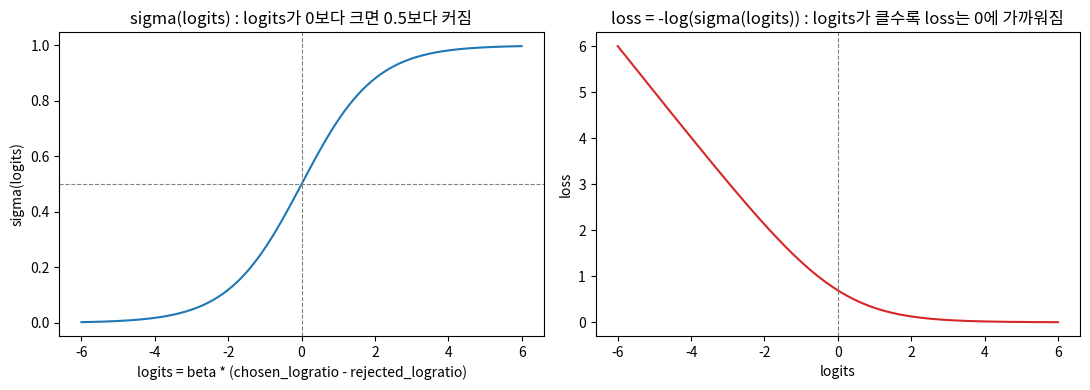

logits = -2 일 때 loss = 2.127  (선호가 반대로 학습됨 -> loss 큼)
logits =  0 일 때 loss = 0.693  (아직 구분 못함 -> log(2)와 같음)
logits = +2 일 때 loss = 0.127  (선호를 잘 학습함 -> loss 작음)


In [3]:
x = torch.linspace(-6, 6, 200)
sig = torch.sigmoid(x)
loss_curve = -F.logsigmoid(x)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(x.numpy(), sig.numpy(), color="tab:blue")
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].axvline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("sigma(logits) : logits가 0보다 크면 0.5보다 커짐")
axes[0].set_xlabel("logits = beta * (chosen_logratio - rejected_logratio)")
axes[0].set_ylabel("sigma(logits)")

axes[1].plot(x.numpy(), loss_curve.numpy(), color="tab:red")
axes[1].axvline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_title("loss = -log(sigma(logits)) : logits가 클수록 loss는 0에 가까워짐")
axes[1].set_xlabel("logits")
axes[1].set_ylabel("loss")

plt.tight_layout()
plt.show()

print(f"logits = -2 일 때 loss = {(-F.logsigmoid(torch.tensor(-2.0))).item():.3f}  (선호가 반대로 학습됨 -> loss 큼)")
print(f"logits =  0 일 때 loss = {(-F.logsigmoid(torch.tensor( 0.0))).item():.3f}  (아직 구분 못함 -> log(2)와 같음)")
print(f"logits = +2 일 때 loss = {(-F.logsigmoid(torch.tensor( 2.0))).item():.3f}  (선호를 잘 학습함 -> loss 작음)")

## 4. 클래스 없이, 손으로 먼저 계산해보기

이제 실제로 "이미 계산되어 있는 로그 확률 4개"에서 DPO loss가 나오는 과정을 클래스 없이, 텐서 연산만으로 한 줄씩 따라가 봅시다.

아래 숫자들은 실제 언어모델이 하나의 (prompt, chosen, rejected) 쌍에 대해 이미 계산해줬다고 **가정한** 값입니다. (이 숫자를 실제 모델에서 뽑아내는 방법은 7장에서 다룹니다.)

In [4]:
# 하나의 (prompt, chosen, rejected) 쌍에 대해, policy/reference 모델이 이미 계산해준
# "응답 전체의 로그 확률"이 아래와 같다고 가정합니다.
policy_chosen_logp      = torch.tensor(-10.0)  # log pi_theta(y_w|x) - 정책 모델의 chosen 로그확률
policy_rejected_logp    = torch.tensor(-15.0)  # log pi_theta(y_l|x) - 정책 모델의 rejected 로그확률
reference_chosen_logp   = torch.tensor(-12.0)  # log pi_ref(y_w|x)   - 참조 모델의 chosen 로그확률
reference_rejected_logp = torch.tensor(-12.0)  # log pi_ref(y_l|x)   - 참조 모델의 rejected 로그확률

# 참고: 로그 확률은 항상 음수입니다 (확률이 0~1 사이이므로 log는 음수).
#      -10이 -15보다 "큰" 값입니다 -> policy는 이미 chosen에 더 높은 확률을 주고 있습니다.

# 1단계: 로그 비율 = log(pi_theta / pi_ref) = log(pi_theta) - log(pi_ref)
chosen_logratio   = policy_chosen_logp   - reference_chosen_logp
rejected_logratio = policy_rejected_logp - reference_rejected_logp
print(f"chosen_logratio   = {chosen_logratio.item():+.2f}   (양수 -> reference보다 chosen을 더 좋아하게 됨)")
print(f"rejected_logratio = {rejected_logratio.item():+.2f}   (음수 -> reference보다 rejected를 덜 좋아하게 됨)")

# 2단계: logits = beta * (chosen_logratio - rejected_logratio)
beta = 0.1
logits = beta * (chosen_logratio - rejected_logratio)
print(f"\nlogits = {beta} * ({chosen_logratio.item():+.2f} - ({rejected_logratio.item():+.2f})) = {logits.item():.3f}")

# 3단계: loss = -log(sigmoid(logits))
loss = -F.logsigmoid(logits)
print(f"loss   = -log(sigmoid({logits.item():.3f})) = {loss.item():.4f}")

# 보조 지표
accuracy = (logits > 0).float()
reward_margin = chosen_logratio - rejected_logratio
print(f"\naccuracy(이 예시 하나) = {accuracy.item():.0f}  (logits > 0 이므로 '올바른 방향'으로 선호 중)")
print(f"reward_margin        = {reward_margin.item():.2f}")

chosen_logratio   = +2.00   (양수 -> reference보다 chosen을 더 좋아하게 됨)
rejected_logratio = -3.00   (음수 -> reference보다 rejected를 덜 좋아하게 됨)

logits = 0.1 * (+2.00 - (-3.00)) = 0.500
loss   = -log(sigmoid(0.500)) = 0.4741

accuracy(이 예시 하나) = 1  (logits > 0 이므로 '올바른 방향'으로 선호 중)
reward_margin        = 5.00


## 5. 이제 재사용 가능한 클래스로 만들기 — `DPOLoss`

위 계산을 매번 손으로 다시 치는 대신, `nn.Module`을 상속하는 클래스로 감싸 두면 어디서든 `dpo_loss_fn(...)`처럼 재사용할 수 있습니다.

> 🐍 **파이썬 들여쓰기(indentation) 주의**
> 파이썬은 중괄호 `{}`가 아니라 **들여쓰기**로 코드 블록(클래스 안, 함수 안, if 안 등)을 구분합니다. 아래처럼 클래스 본문의 들여쓰기 폭이 한 군데라도 다르면 `IndentationError`가 나거나, 파이썬이 에러를 못 잡아내는 경우엔 코드가 전혀 다른 의미로 실행됩니다.
> ```python
> class Foo:
>     def method_a(self):   # 클래스 본문 = 4칸 들여쓰기
>         return 1           # method_a 본문 = 8칸 들여쓰기 (method_a보다 한 단계 더)
>     def method_b(self):   # method_a와 반드시 같은 4칸
>         return 2
> ```
> 아래 `DPOLoss` 클래스를 직접 타이핑해 볼 때도 이 규칙을 꼭 지켜 주세요.

`nn.Module`을 상속하지만, 이 클래스는 `nn.Linear`와 달리 학습되는 파라미터(가중치)가 하나도 없습니다. 그런데도 `nn.Module`을 상속하는 이유는:
- PyTorch의 다른 loss들(`nn.CrossEntropyLoss` 등)과 사용 방식을 통일하기 위해서
- 나중에 `beta`를 학습 가능한 파라미터로 바꾸는 등 확장을 하고 싶을 때 그대로 이어서 확장할 수 있기 때문입니다.

In [5]:
class DPOLoss(nn.Module):
    """DPO (Direct Preference Optimization) Loss 직접 구현

    논문: Rafailov et al., "Direct Preference Optimization", NeurIPS 2023

    핵심 수식:
        L_DPO = -E[ log(sigmoid( beta * (chosen_logratio - rejected_logratio) )) ]
        chosen_logratio   = log(pi_theta(y_w|x)) - log(pi_ref(y_w|x))
        rejected_logratio = log(pi_theta(y_l|x)) - log(pi_ref(y_l|x))
    """

    def __init__(self, beta=0.1, loss_type="sigmoid"):
        super().__init__()
        self.beta = beta
        self.loss_type = loss_type

    def forward(self, policy_chosen_logps, policy_rejected_logps,
                reference_chosen_logps, reference_rejected_logps):
        """
        아래 4개 인자는 모두 shape (batch_size,) 텐서입니다 - 배치 안의 각 예시마다 값 1개.

        policy_chosen_logps:      log pi_theta(y_w|x) - 정책 모델의 chosen 로그 확률
        policy_rejected_logps:    log pi_theta(y_l|x) - 정책 모델의 rejected 로그 확률
        reference_chosen_logps:   log pi_ref(y_w|x)   - 참조 모델의 chosen 로그 확률
        reference_rejected_logps: log pi_ref(y_l|x)   - 참조 모델의 rejected 로그 확률
        """
        # 1단계: 로그 비율 계산 = log(pi_theta) - log(pi_ref)
        chosen_logratios = policy_chosen_logps - reference_chosen_logps
        rejected_logratios = policy_rejected_logps - reference_rejected_logps

        # 2단계: 두 로그비율의 차이에 beta를 곱함
        #        (policy가 reference 대비, chosen을 rejected보다 얼마나 더
        #         선호하게 됐는지를 나타내는 implicit reward 차이입니다)
        logits = self.beta * (chosen_logratios - rejected_logratios)

        # 3단계: loss 계산 (두 가지 방식 지원)
        if self.loss_type == "sigmoid":
            # 원 논문의 기본 방식: 이진 분류(chosen vs rejected)의 로지스틱 손실과 같은 형태
            loss = -F.logsigmoid(logits).mean()
        elif self.loss_type == "hinge":
            # SLiC 스타일의 힌지(hinge) 손실: logits가 1 이상이면 loss=0, 그 밖에는 선형으로 증가
            loss = F.relu(1 - logits).mean()
        else:
            raise ValueError(
                f"알 수 없는 loss_type입니다: '{self.loss_type}' "
                f"('sigmoid' 또는 'hinge'만 지원합니다)"
            )

        # 4단계: 보조 지표 계산 (학습에는 쓰이지 않고, 진행 상황 모니터링용)
        with torch.no_grad():
            # accuracy: logits > 0 인 비율 = policy의 implicit reward가
            #           chosen을 rejected보다 높게 평가한 예시의 비율
            accuracy = (logits > 0).float().mean()
            # reward_margin: beta를 곱하기 전, 두 로그비율 차이 자체의 평균
            reward_margin = (chosen_logratios - rejected_logratios).mean()

        return loss, accuracy, reward_margin


# 방금 손으로 계산한 값과 클래스 결과가 똑같이 나오는지 검증합니다.
dpo_loss_fn = DPOLoss(beta=0.1, loss_type="sigmoid")
loss_c, acc_c, margin_c = dpo_loss_fn(
    policy_chosen_logp.unsqueeze(0), policy_rejected_logp.unsqueeze(0),
    reference_chosen_logp.unsqueeze(0), reference_rejected_logp.unsqueeze(0),
)
print(f"클래스로 계산한 loss   = {loss_c.item():.4f}  (4장에서 손으로 계산한 값과 같아야 합니다)")
print(f"클래스로 계산한 acc    = {acc_c.item():.4f}")
print(f"클래스로 계산한 margin = {margin_c.item():.4f}")

assert torch.isclose(loss_c, loss), "손으로 계산한 값과 클래스 결과가 다릅니다!"
print("\n검증 완료: 손으로 계산한 값과 클래스 구현 결과가 일치합니다.")

클래스로 계산한 loss   = 0.4741  (4장에서 손으로 계산한 값과 같아야 합니다)
클래스로 계산한 acc    = 1.0000
클래스로 계산한 margin = 5.0000

검증 완료: 손으로 계산한 값과 클래스 구현 결과가 일치합니다.


## 6. 배치(batch)로 확장하고, 여러 상황 비교하기

실제 학습에서는 한 번에 여러 개의 (chosen, rejected) 쌍을 묶어서(batch) 처리합니다. `DPOLoss`는 이미 텐서 연산으로 구현되어 있으므로, 입력 shape를 `(batch_size,)`로 바꿔주기만 하면 그대로 동작합니다.

이번에는 세 가지 상황을 만들어 비교해 봅니다.

1. **정상적으로 학습된 배치** — 전부 chosen을 더 선호하게 됨
2. **학습 초반** — 아직 변화가 거의 없음
3. **거꾸로 학습된 배치** — chosen보다 rejected를 더 선호하게 됨 (loss가 커야 정상입니다)

In [6]:
torch.manual_seed(0)
batch_size = 4

def make_batch(chosen_shift, rejected_shift):
    """policy와 reference의 로그확률 차이를 chosen_shift / rejected_shift로 흉내내는
    가짜 배치를 만듭니다 (실제 모델 없이, 개념 확인용 예시 데이터)."""
    base = torch.randn(batch_size) * 2 - 20        # reference 로그확률처럼 보이는 랜덤 값
    reference_chosen = base
    reference_rejected = base + torch.randn(batch_size) * 0.5
    policy_chosen = reference_chosen + chosen_shift + torch.randn(batch_size) * 0.3
    policy_rejected = reference_rejected + rejected_shift + torch.randn(batch_size) * 0.3
    return policy_chosen, policy_rejected, reference_chosen, reference_rejected

scenarios = {
    "(1) 정상 학습 - chosen 선호 강화":   make_batch(chosen_shift=+3.0, rejected_shift=-1.0),
    "(2) 학습 초반 - 변화 거의 없음":     make_batch(chosen_shift=+0.2, rejected_shift=-0.1),
    "(3) 거꾸로 학습 - 잘못된 방향":      make_batch(chosen_shift=-2.0, rejected_shift=+2.0),
}

for name, (pc, pr, rc, rr) in scenarios.items():
    s_loss, s_acc, s_margin = dpo_loss_fn(pc, pr, rc, rr)
    print(f"{name}")
    print(f"    loss={s_loss.item():.4f}   accuracy={s_acc.item()*100:.0f}%   reward_margin={s_margin.item():+.3f}\n")

(1) 정상 학습 - chosen 선호 강화
    loss=0.5156   accuracy=100%   reward_margin=+3.938

(2) 학습 초반 - 변화 거의 없음
    loss=0.6751   accuracy=75%   reward_margin=+0.368

(3) 거꾸로 학습 - 잘못된 방향
    loss=0.9099   accuracy=0%   reward_margin=-3.947



## 7. 그런데 실제로 `policy_chosen_logps`는 어떻게 구하나요?

지금까지는 로그 확률 값이 "이미 계산되어 있다"고 가정했습니다. 실제로 언어모델에서 이 값을 어떻게 뽑아내는지 살펴봅시다.

언어모델은 문장 전체의 확률을 한 번에 알려주지 않습니다. 대신 "지금까지의 토큰들을 보고, 다음 토큰이 무엇일지"에 대한 확률 분포를 토큰 위치마다 하나씩 내놓습니다. 문장 하나의 로그 확률은 이 토큰별 로그 확률을 **모두 더한 값**입니다.

$$
\log \pi(y \mid x) = \sum_{t} \log \pi(y_t \mid x, y_{<t})
$$

여기서 중요한 것이 두 가지 있습니다.

1. **프롬프트(prompt) 부분은 더하지 않습니다.** 우리가 관심있는 건 "이 답변을 낼 확률"이지 "이 질문이 나올 확률"이 아니기 때문입니다. 그래서 실제 구현에서는 어떤 토큰이 prompt이고 어떤 토큰이 response(답변)인지 표시하는 **마스크(mask)**가 필요합니다.
2. **평균이 아니라 합(sum)입니다.** 흔한 실수 중 하나가, 언어모델의 (평균) cross-entropy loss에 마이너스를 붙여서 `log pi(y|x)`인 것처럼 쓰는 것입니다 (예: `-model(...).loss`). 하지만 cross-entropy loss는 토큰 전체에 대한 **평균**이고, DPO 수식이 필요로 하는 건 응답 토큰들의 로그확률 **합**입니다. 답변 길이가 다르면 평균과 합의 차이가 더 벌어지고, 게다가 이 평균에는 prompt 토큰까지 섞여 있어 이중으로 부정확해집니다. 아래에서는 "합"을 직접 구현합니다.

작은 예시로 이 과정을 눈으로 확인해 봅시다.

In [7]:
# 아주 작은 예시로 "토큰별 로그확률 -> 마스킹 -> 합"의 과정을 확인해 봅니다.
# vocab_size=4인 미니 세계를 가정합니다: 0='<A>', 1='<B>', 2='<C>', 3='<D>'

# 시퀀스: [A, B, C, D] 라는 4개 토큰짜리 문장이 있고,
# 이 중 앞 2개(A, B)는 prompt, 뒤 2개(C, D)는 response라고 가정합니다.
toy_ids  = torch.tensor([[0, 1, 2, 3]])              # shape (1, 4) = (batch=1, seq_len=4)
toy_mask = torch.tensor([[0., 0., 1., 1.]])          # 0=prompt, 1=response

# 모델이 내놓은 "다음 토큰 예측 로짓"이 이미 계산되어 있다고 가정합니다.
# shape (1, 4, 4) = (batch, seq_len, vocab_size)
torch.manual_seed(1)
toy_logits = torch.randn(1, 4, 4)

# 다음 토큰 예측이므로, 위치 t의 로짓은 위치 t+1의 토큰을 예측합니다.
# 즉 toy_logits[:, t, :] 는 toy_ids[:, t+1] 에 대한 예측입니다.
# -> 마지막 위치(D)의 로짓은 "그 다음 토큰"이 없으므로 쓰지 않고,
#    맨 앞(A)은 "누군가 예측해서 맞힌 대상"이 아니라 시작점이므로 라벨에서 제외합니다.
shift_logits = toy_logits[:, :-1, :]     # (1, 3, 4)  -> A, B, C 위치에서의 예측
shift_labels = toy_ids[:, 1:]            # (1, 3)     -> 실제 다음 토큰: B, C, D
shift_mask   = toy_mask[:, 1:]           # (1, 3)     -> B, C, D 가 각각 response인지 (0, 1, 1)

log_probs = F.log_softmax(shift_logits, dim=-1)   # (1, 3, 4) 각 위치에서 4개 토큰에 대한 로그확률 분포

# gather: "실제로 나온 토큰"의 로그확률만 뽑아냅니다.
token_logps = torch.gather(log_probs, dim=2, index=shift_labels.unsqueeze(-1)).squeeze(-1)  # (1, 3)
print("위치별(B,C,D 예측) 로그확률:", token_logps)

# response가 아닌 위치는 0으로 만들어서 합산에서 제외합니다.
token_logps_masked = token_logps * shift_mask
print("마스킹 후 (B 예측은 prompt라 0이 됨):", token_logps_masked)

# 최종: response 부분만 '합'해서 문장 전체의 로그확률을 얻습니다.
sequence_logp = token_logps_masked.sum(dim=1)
print("\nsequence_logp (C, D 두 토큰의 로그확률 합) =", sequence_logp)

위치별(B,C,D 예측) 로그확률: tensor([[-1.0936, -1.6848, -1.3773]])
마스킹 후 (B 예측은 prompt라 0이 됨): tensor([[-0.0000, -1.6848, -1.3773]])

sequence_logp (C, D 두 토큰의 로그확률 합) = tensor([-3.0621])


## 8. 미니 실습 준비 — 아주 작은 토크나이저와 모델 만들기

실제 DPO는 수십억 개 파라미터를 가진 사전학습 LLM과, HuggingFace 같은 라이브러리의 서브워드(subword) 토크나이저를 사용합니다. 하지만 그런 모델은 다운로드 용량도 크고 보통 GPU가 필요해서, 처음 공부할 때 손으로 실행해보기에는 부담스럽습니다.

그래서 이 실습에서는 다음과 같이 준비합니다.

- **토크나이저**: 가장 단순한 **글자 단위(character-level)** 토크나이저를 직접 만듭니다. (실제 LLM은 BPE 같은 서브워드 토크나이저를 쓰지만, 원리를 이해하는 데는 글자 단위가 훨씬 직관적입니다.)
- **모델**: Embedding + GRU(순환 신경망) + Linear로 이루어진, 파라미터 몇 천 개짜리 초소형 언어모델을 사용합니다.

> 💡 **DPO는 모델 구조와 무관합니다.** GRU든, LSTM이든, Transformer든 — "프롬프트가 주어졌을 때 다음 토큰의 확률분포를 내놓는" 모델이기만 하면 DPO를 그대로 적용할 수 있습니다. 여기서는 설명을 단순하게 하기 위해 가장 가벼운 구조를 골랐을 뿐입니다. (Transformer의 attention 구조 자체는 이 튜토리얼 시리즈의 다른 노트북에서 다룹니다.)

이 미니 모델은 CPU에서 몇 초 안에 학습이 끝나므로, 지금 바로 실행하면서 loss/accuracy/margin이 실제로 움직이는 것을 눈으로 볼 수 있습니다.

In [8]:
# ── 토이 선호 데이터셋: (prompt, chosen, rejected) ──
# chosen은 "더 도움이 되고 친절하고 정확한" 답변, rejected는 일부러 그 반대로 만들었습니다.
preference_data = [
    ("오늘 기분이 안 좋아",
     "무슨 일 있었어? 힘들었겠다, 얘기 들어줄게.",
     "그런가보네."),
    ("1 더하기 1은?",
     "1 더하기 1은 2입니다.",
     "1 더하기 1은 5입니다."),
    ("고양이에 대해 알려줘",
     "고양이는 사람과 친하게 지내는 작은 반려동물입니다.",
     "몰라요."),
    ("파이썬이 뭐야?",
     "파이썬은 배우기 쉬운 프로그래밍 언어입니다.",
     "그냥 뱀 이름인데요."),
    ("여행지 추천해줘",
     "제주도는 바다와 자연이 아름다운 여행지입니다.",
     "아 몰라 귀찮아."),
    ("한국의 수도는?",
     "한국의 수도는 서울입니다.",
     "한국의 수도는 부산입니다."),
]
print(f"학습 예시 개수: {len(preference_data)}")

# ── 아주 단순한 글자 단위 토크나이저 ──
PROMPT_TEMPLATE = "User: {prompt}\nAssistant: "

def build_full_text(prompt, response):
    """prompt와 response를 하나의 문자열로 이어 붙입니다.
    반환값: (prefix, 전체 문자열) — prefix는 'User: (prompt)' 다음 줄의 'Assistant: ' 까지입니다."""
    prefix = PROMPT_TEMPLATE.format(prompt=prompt)
    return prefix, prefix + response

# vocab(사용되는 모든 글자의 집합)을 데이터에 등장하는 글자로부터 만듭니다.
all_chars = set()
for prompt, chosen, rejected in preference_data:
    _, full_chosen = build_full_text(prompt, chosen)
    _, full_rejected = build_full_text(prompt, rejected)
    all_chars.update(full_chosen)
    all_chars.update(full_rejected)

vocab = sorted(all_chars)
char_to_id = {ch: i for i, ch in enumerate(vocab)}
id_to_char = {i: ch for ch, i in char_to_id.items()}
vocab_size = len(vocab)
print(f"vocab 크기(사용되는 전체 글자 수): {vocab_size}")

def encode(text):
    """문자열 -> 토큰 id 리스트"""
    return [char_to_id[ch] for ch in text]

def decode(ids):
    """토큰 id 리스트 -> 문자열"""
    return "".join(id_to_char[i] for i in ids)

# 인코딩/디코딩이 잘 되는지, 데이터셋에 있는 문장으로 확인합니다.
sample_prefix, sample_full = build_full_text(preference_data[0][0], preference_data[0][1])
print(f"\n인코딩 테스트: {sample_full!r}")
encoded = encode(sample_full)
print("-> 앞부분 토큰 id:", encoded[:10], "...")
print("디코딩해서 원래 문장과 같은지:", decode(encoded) == sample_full)

학습 예시 개수: 6
vocab 크기(사용되는 전체 글자 수): 110

인코딩 테스트: 'User: 오늘 기분이 안 좋아\nAssistant: 무슨 일 있었어? 힘들었겠다, 얘기 들어줄게.'
-> 앞부분 토큰 id: [10, 16, 12, 15, 7, 1, 78, 31, 1, 26] ...
디코딩해서 원래 문장과 같은지: True


In [9]:
class TinyLanguageModel(nn.Module):
    """아주 작은 캐릭터 단위 언어모델: Embedding -> GRU -> Linear

    입력: 토큰 id 시퀀스 (batch, seq_len)
    출력: 각 위치에서 "다음 토큰"에 대한 로짓 (batch, seq_len, vocab_size)
    """
    def __init__(self, vocab_size, d_model=32, hidden_size=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)          # 토큰 id -> 벡터
        self.gru = nn.GRU(d_model, hidden_size, batch_first=True)    # 순서 정보를 반영해 상태를 업데이트
        self.output_head = nn.Linear(hidden_size, vocab_size)        # 상태 -> 다음 토큰 로짓

    def forward(self, input_ids):
        x = self.embedding(input_ids)                 # (batch, seq_len, d_model)
        hidden_states, _ = self.gru(x)                 # (batch, seq_len, hidden_size)
        logits = self.output_head(hidden_states)        # (batch, seq_len, vocab_size)
        return logits


def sequence_logprob(model, input_ids, response_mask):
    """response_mask로 표시된 부분(=response 토큰들)에 대한 로그확률의 '합'을 구합니다.
    7장의 미니 예제와 완전히 같은 원리이며, 여기서는 실제 모델에 대해 동작하도록 함수로 만든 것입니다.

    input_ids:      (batch, seq_len) - prompt+response 전체 토큰 id
    response_mask:  (batch, seq_len) - 1이면 response 토큰, 0이면 prompt 토큰
    반환값:          (batch,) - 각 시퀀스의 log(pi(response | prompt))
    """
    logits = model(input_ids)                        # (batch, seq_len, vocab_size)

    shift_logits = logits[:, :-1, :]
    shift_labels = input_ids[:, 1:]
    shift_mask = response_mask[:, 1:]

    log_probs = F.log_softmax(shift_logits, dim=-1)
    token_logps = torch.gather(log_probs, dim=2, index=shift_labels.unsqueeze(-1)).squeeze(-1)
    token_logps = token_logps * shift_mask

    # 합(sum)이지 평균(mean)이 아닙니다 — 7장에서 설명한 이유를 꼭 기억하세요.
    return token_logps.sum(dim=1)

## 9. 학습 예시를 모델 입력 형태로 바꾸기

각 (prompt, response) 쌍을 "토큰 id 시퀀스"와 "response_mask"로 바꾸는 함수를 만들고, 실제로 하나를 눈으로 확인해 봅니다.

In [10]:
def build_example(prompt, response):
    """(prompt, response) -> (input_ids, response_mask) 텐서로 변환합니다."""
    prefix, full_text = build_full_text(prompt, response)
    ids = encode(full_text)
    mask = [0] * len(prefix) + [1] * (len(full_text) - len(prefix))
    return torch.tensor([ids]), torch.tensor([mask], dtype=torch.float32)


# 실제로 하나를 만들어서, prefix(prompt 부분)와 response 부분이 어떻게 나뉘는지 확인합니다.
demo_prompt, demo_chosen = preference_data[0][0], preference_data[0][1]
demo_prefix, demo_full = build_full_text(demo_prompt, demo_chosen)
demo_ids, demo_mask = build_example(demo_prompt, demo_chosen)

print(f"input_ids shape: {demo_ids.shape},  response_mask shape: {demo_mask.shape}\n")
print("전체 문자열:")
print(repr(demo_full))
print()
print(f"prefix (=prompt, mask 0으로 채워짐)  : {demo_prefix!r}")
print(f"response (mask 1로 채워짐)          : {demo_chosen!r}")
print()
print("mask 리스트 (0=prompt, 1=response):")
print([int(m) for m in demo_mask[0].tolist()])

print("\n경계 부분만 확대해서 보면:")
boundary = len(demo_prefix)
for i in range(max(0, boundary - 5), min(len(demo_full), boundary + 5)):
    marker = "   <- 여기부터 response 시작" if i == boundary else ""
    print(f"  [{i:2d}] {demo_full[i]!r:>6}   mask={int(demo_mask[0, i].item())}{marker}")

input_ids shape: torch.Size([1, 54]),  response_mask shape: torch.Size([1, 54])

전체 문자열:
'User: 오늘 기분이 안 좋아\nAssistant: 무슨 일 있었어? 힘들었겠다, 얘기 들어줄게.'

prefix (=prompt, mask 0으로 채워짐)  : 'User: 오늘 기분이 안 좋아\nAssistant: '
response (mask 1로 채워짐)          : '무슨 일 있었어? 힘들었겠다, 얘기 들어줄게.'

mask 리스트 (0=prompt, 1=response):
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

경계 부분만 확대해서 보면:
  [24]    'a'   mask=0
  [25]    'n'   mask=0
  [26]    't'   mask=0
  [27]    ':'   mask=0
  [28]    ' '   mask=0
  [29]    '무'   mask=1   <- 여기부터 response 시작
  [30]    '슨'   mask=1
  [31]    ' '   mask=1
  [32]    '일'   mask=1
  [33]    ' '   mask=1


## 10. Reference 모델 만들기 & 학습 준비

DPO에서 reference 모델은 **학습 내내 고정된(frozen)** 모델입니다. 보통은 SFT를 마친 모델을 그대로 복사해서 사용합니다. 여기서는 간단히, 방금 만든 모델을 초기 상태에서 **완전히 독립적인 복사본**으로 하나 떼어내어 reference로 씁니다.

> 💡 **왜 `ref_model = model`이 아니라 `copy.deepcopy(model)`을 쓸까요?**
> 단순히 `ref_model = model`이라고 쓰면 두 변수가 **같은 객체를 가리키는 별명**이 될 뿐이라, `model`의 가중치가 바뀌면 `ref_model`도 같이 바뀌어 버립니다. `copy.deepcopy`는 가중치까지 통째로 복사한 **별도의 객체**를 만들어서, policy가 아무리 학습되어도 `ref_model`은 처음 상태 그대로 남아있게 합니다.

In [11]:
# 재현성을 위해, 이 섹션부터는 시드를 다시 고정합니다.
random.seed(0)
torch.manual_seed(0)

model = TinyLanguageModel(vocab_size=vocab_size, d_model=32, hidden_size=64)

ref_model = copy.deepcopy(model)    # policy의 '초기 상태'를 그대로 복제
ref_model.eval()                     # reference는 항상 평가(eval) 모드로 둡니다 (dropout 등 비활성화)
for param in ref_model.parameters():
    param.requires_grad = False      # reference는 절대 업데이트되지 않도록 그래디언트 계산을 막습니다

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
dpo_loss_fn = DPOLoss(beta=0.1, loss_type="sigmoid")

n_params = sum(p.numel() for p in model.parameters())
print(f"policy 모델 파라미터 수: {n_params:,}개  (참고: 실제 LLM은 보통 수십억 개입니다)")

# 각 (prompt, chosen, rejected)를 미리 텐서로 변환해 둡니다.
examples = [
    build_example(prompt, chosen) + build_example(prompt, rejected)
    for prompt, chosen, rejected in preference_data
]
print(f"준비된 학습 예시: {len(examples)}개")

policy 모델 파라미터 수: 29,486개  (참고: 실제 LLM은 보통 수십억 개입니다)
준비된 학습 예시: 6개


## 11. DPO 학습 루프 실행하기

이제 원래 실습 코드에 있던 `train_dpo` 함수를, 위에서 만든 `sequence_logprob` 함수를 사용해 제대로 동작하도록 완성합니다. 실제 HuggingFace 모델을 쓸 때도 `model`, `ref_model`, 토크나이저 부분만 진짜 모델/토크나이저로 바꾸면 거의 같은 구조를 그대로 쓸 수 있습니다.

> ⚠️ **학습률(learning rate)에 대한 참고**: 실제 DPO 논문/구현에서는 이미 잘 학습된 거대 모델을 아주 살짝만 조정하기 때문에 `lr=5e-7`처럼 매우 작은 값을 씁니다. 여기서는 방금 막 랜덤하게 초기화된 초소형 모델을 짧은 시간 안에 학습시키는 것이 목적이므로, 훨씬 큰 `lr=5e-4`를 사용합니다. **실제 사전학습 LLM에 적용할 때는 반드시 훨씬 작은 학습률로 되돌려야 합니다.**

In [12]:
def train_dpo(model, ref_model, examples, dpo_loss_fn, optimizer, epochs=80):
    """DPO 학습 전체 루프.

    examples: [(chosen_ids, chosen_mask, rejected_ids, rejected_mask), ...] 형태의 리스트
    반환값:   epoch별 평균 loss/accuracy/margin 기록(dict)
    """
    ref_model.eval()
    model.train()

    order = list(range(len(examples)))
    history = {"loss": [], "accuracy": [], "margin": []}

    for epoch in range(epochs):
        total_loss, total_acc, total_margin = 0.0, 0.0, 0.0
        random.shuffle(order)  # 매 epoch마다 예시 순서를 섞어, 순서에 대한 편향을 줄입니다.

        for idx in order:
            chosen_ids, chosen_mask, rejected_ids, rejected_mask = examples[idx]

            # policy 모델의 로그확률 (그래디언트 필요 O — 학습 대상)
            policy_chosen_logps = sequence_logprob(model, chosen_ids, chosen_mask)
            policy_rejected_logps = sequence_logprob(model, rejected_ids, rejected_mask)

            # reference 모델의 로그확률 (그래디언트 필요 X — 고정된 비교 기준일 뿐)
            with torch.no_grad():
                reference_chosen_logps = sequence_logprob(ref_model, chosen_ids, chosen_mask)
                reference_rejected_logps = sequence_logprob(ref_model, rejected_ids, rejected_mask)

            loss, accuracy, margin = dpo_loss_fn(
                policy_chosen_logps, policy_rejected_logps,
                reference_chosen_logps, reference_rejected_logps,
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 그래디언트 폭주 방지
            optimizer.step()

            total_loss += loss.item()
            total_acc += accuracy.item()
            total_margin += margin.item()

        n = len(examples)
        history["loss"].append(total_loss / n)
        history["accuracy"].append(total_acc / n)
        history["margin"].append(total_margin / n)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"epoch {epoch+1:4d}  loss={total_loss/n:.4f}  "
                  f"accuracy={total_acc/n*100:5.1f}%  margin={total_margin/n:+.3f}")

    return history


history = train_dpo(model, ref_model, examples, dpo_loss_fn, optimizer, epochs=80)

epoch    1  loss=0.6896  accuracy= 66.7%  margin=+0.072


epoch   10  loss=0.3912  accuracy=100.0%  margin=+8.137


epoch   20  loss=0.1987  accuracy=100.0%  margin=+20.142


epoch   30  loss=0.1416  accuracy=100.0%  margin=+25.078


epoch   40  loss=0.1035  accuracy=100.0%  margin=+28.826


epoch   50  loss=0.0715  accuracy=100.0%  margin=+32.419


epoch   60  loss=0.0460  accuracy=100.0%  margin=+36.135


epoch   70  loss=0.0300  accuracy=100.0%  margin=+39.724


epoch   80  loss=0.0203  accuracy=100.0%  margin=+43.132


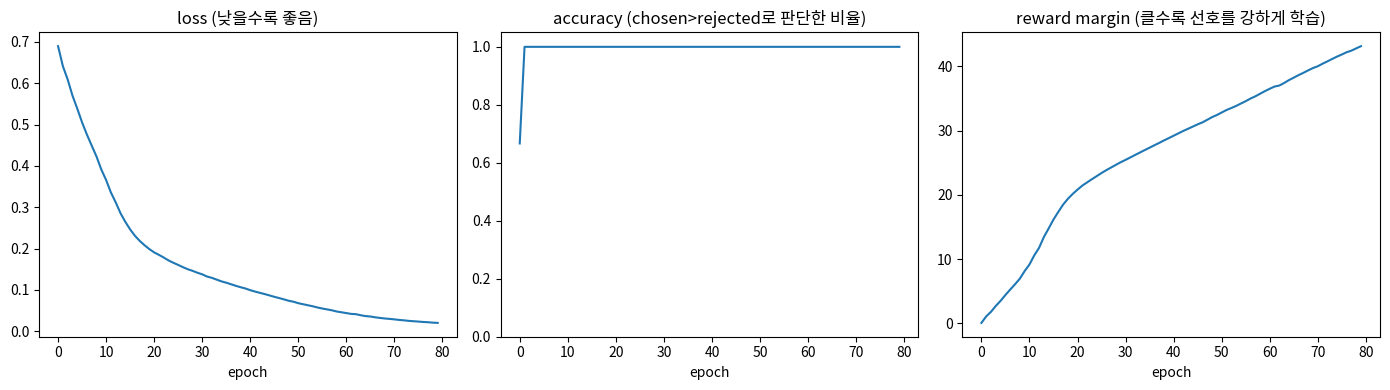

눈에 띄는 점: accuracy는 예시가 몇 개뿐이라 비교적 일찍 100%에 도달하지만,
loss와 margin은 그 이후에도 계속 조금씩 개선됩니다.
-> accuracy는 '방향(맞았는지/틀렸는지)'만 보는 거친 지표이고,
   loss/margin은 '얼마나 확실하게' 맞았는지까지 반영하는 지표이기 때문입니다.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history["loss"]);      axes[0].set_title("loss (낮을수록 좋음)");                         axes[0].set_xlabel("epoch")
axes[1].plot(history["accuracy"]);  axes[1].set_title("accuracy (chosen>rejected로 판단한 비율)"); axes[1].set_xlabel("epoch"); axes[1].set_ylim(0, 1.05)
axes[2].plot(history["margin"]);    axes[2].set_title("reward margin (클수록 선호를 강하게 학습)");     axes[2].set_xlabel("epoch")
plt.tight_layout()
plt.show()

print("눈에 띄는 점: accuracy는 예시가 몇 개뿐이라 비교적 일찍 100%에 도달하지만,")
print("loss와 margin은 그 이후에도 계속 조금씩 개선됩니다.")
print("-> accuracy는 '방향(맞았는지/틀렸는지)'만 보는 거친 지표이고,")
print("   loss/margin은 '얼마나 확실하게' 맞았는지까지 반영하는 지표이기 때문입니다.")

## 12. 학습이 실제로 잘 됐는지, 예시별로 확인하기

평균 지표만 보면 감이 잘 안 올 수 있으니, 각 예시별로 "policy의 implicit reward margin"이 학습 전(=0, policy와 reference가 같으므로)과 학습 후에 어떻게 달라졌는지 직접 확인합니다.

$$
\text{margin}_i = \big(\log\pi_\theta(y_w|x)-\log\pi_{ref}(y_w|x)\big) - \big(\log\pi_\theta(y_l|x)-\log\pi_{ref}(y_l|x)\big)
$$

이 값이 **모든 예시에서 양수**라면, 학습된 policy가 예외 없이 "chosen을 rejected보다 더 선호하는 방향"으로 움직였다는 뜻입니다.

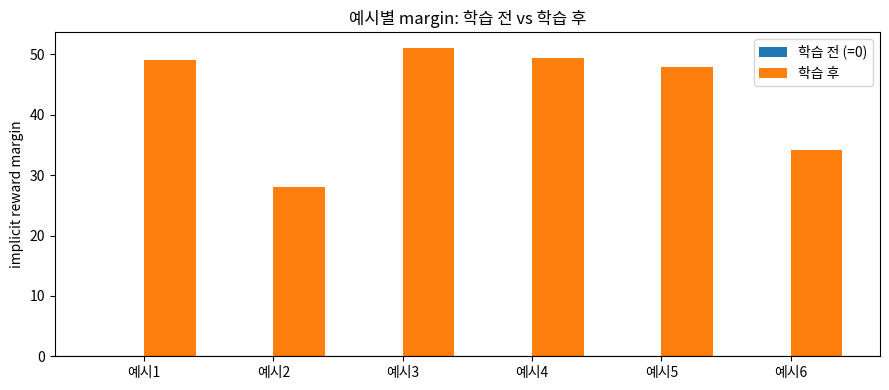

학습 후 margin이 양수인 예시: 6/6개
  예시1 ('오늘 기분이 안 좋아'): margin = +49.16
  예시2 ('1 더하기 1은?'): margin = +28.10
  예시3 ('고양이에 대해 알려줘'): margin = +51.11
  예시4 ('파이썬이 뭐야?'): margin = +49.44
  예시5 ('여행지 추천해줘'): margin = +47.99
  예시6 ('한국의 수도는?'): margin = +34.24


In [14]:
def per_example_margins(policy, ref):
    """각 학습 예시에 대해 policy 기준 implicit reward margin을 계산합니다."""
    margins = []
    with torch.no_grad():
        for chosen_ids, chosen_mask, rejected_ids, rejected_mask in examples:
            pc = sequence_logprob(policy, chosen_ids, chosen_mask)
            pr = sequence_logprob(policy, rejected_ids, rejected_mask)
            rc = sequence_logprob(ref, chosen_ids, chosen_mask)
            rr = sequence_logprob(ref, rejected_ids, rejected_mask)
            margins.append(((pc - rc) - (pr - rr)).item())
    return margins

before = per_example_margins(ref_model, ref_model)   # ref vs ref -> 항상 0 (검증용)
after = per_example_margins(model, ref_model)         # 학습된 policy vs ref

labels = [f"예시{i+1}" for i in range(len(preference_data))]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(labels))
ax.bar(x - 0.2, before, width=0.4, label="학습 전 (=0)")
ax.bar(x + 0.2, after, width=0.4, label="학습 후")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("implicit reward margin")
ax.set_title("예시별 margin: 학습 전 vs 학습 후")
ax.legend()
plt.tight_layout()
plt.show()

n_positive = sum(1 for m in after if m > 0)
print(f"학습 후 margin이 양수인 예시: {n_positive}/{len(after)}개")
for i, (p, m) in enumerate(zip(preference_data, after)):
    print(f"  예시{i+1} ('{p[0]}'): margin = {m:+.2f}")

## 13. β(beta)를 바꾸면 어떻게 될까? — 빠르게 실험해보기

모델을 다시 학습시키지 않고도, 5장에서 만든 `DPOLoss`만으로 β의 역할을 바로 확인할 수 있습니다. 같은 "선호 차이"(로그비율 차이)에 대해, β가 커질수록 loss가 얼마나 더 민감하게 반응하는지 살펴봅니다. (2장에서 손으로 계산해봤던 것을 더 다양한 β 값으로 넓혀서 재확인하는 것입니다.)

  beta |   logits |     loss
------------------------------
  0.01 |    0.030 |   0.6783
  0.05 |    0.150 |   0.6210
   0.1 |    0.300 |   0.5544
   0.3 |    0.900 |   0.3412
   0.5 |    1.500 |   0.2014
   1.0 |    3.000 |   0.0486
   2.0 |    6.000 |   0.0025


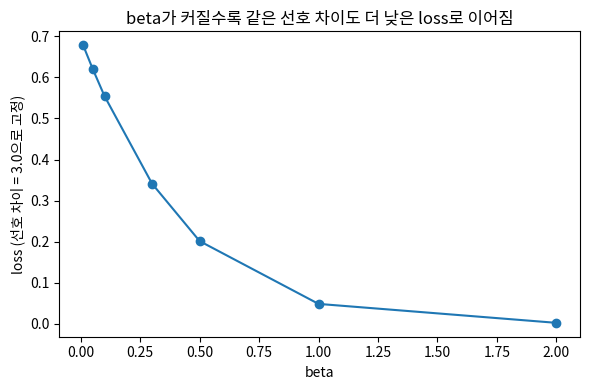


해석: beta가 작으면(예: 0.01) policy가 reference에서 크게 벗어나도 loss가 별로 줄지 않아 학습 신호가 약합니다.
      beta가 크면(예: 2.0) 같은 정도의 선호 차이만으로도 loss가 빠르게 0에 가까워집니다.
      즉 beta는 'policy가 reference로부터 얼마나 자유롭게 벗어날 수 있는지'를 조절하는 손잡이입니다.


In [15]:
fixed_logratio_diff = torch.tensor(3.0)   # chosen_logratio - rejected_logratio 를 3.0으로 고정
betas = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0]

print(f"{'beta':>6} | {'logits':>8} | {'loss':>8}")
print("-" * 30)
losses = []
for b in betas:
    logits = b * fixed_logratio_diff
    b_loss = -F.logsigmoid(logits)
    losses.append(b_loss.item())
    print(f"{b:>6} | {logits.item():>8.3f} | {b_loss.item():>8.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(betas, losses, marker="o")
ax.set_xlabel("beta")
ax.set_ylabel("loss (선호 차이 = 3.0으로 고정)")
ax.set_title("beta가 커질수록 같은 선호 차이도 더 낮은 loss로 이어짐")
plt.tight_layout()
plt.show()

print("\n해석: beta가 작으면(예: 0.01) policy가 reference에서 크게 벗어나도 loss가 별로 줄지 않아 학습 신호가 약합니다.")
print("      beta가 크면(예: 2.0) 같은 정도의 선호 차이만으로도 loss가 빠르게 0에 가까워집니다.")
print("      즉 beta는 'policy가 reference로부터 얼마나 자유롭게 벗어날 수 있는지'를 조절하는 손잡이입니다.")

## 14. 정리 — DPO vs RLHF(PPO)

| 구분 | RLHF (PPO 기반) | DPO |
|---|---|---|
| 학습 단계 | SFT → Reward Model 학습 → PPO 강화학습 (3단계) | SFT → DPO 직접 최적화 (2단계) |
| 동시에 다루는 모델 수 | 정책, 참조, 보상 모델, 가치 함수 (최대 4개) | 정책, 참조 (2개) |
| 보상 신호 | 별도로 학습한 Reward Model이 실시간으로 점수를 매김 | $\pi_\theta$와 $\pi_{ref}$의 로그비율 자체가 암묵적(implicit) 보상 역할 |
| 학습 방식 | 강화학습(PPO) — 샘플링, advantage 추정 등 필요 | 지도학습에 가까운 분류 손실 — 구현이 비교적 단순 |
| 데이터 활용 방식 | 학습 중 정책이 직접 생성한 응답을 사용 (on-policy) | 미리 수집된 (chosen, rejected) 쌍만 있으면 됨 (off-policy) |

**DPO의 장점**
- ✅ 별도의 Reward Model이 필요 없어 메모리/구현 복잡도가 줄어듭니다.
- ✅ PPO 특유의 불안정성(하이퍼파라미터 민감도, 샘플링 비용) 없이, 지도학습과 비슷한 방식으로 학습할 수 있습니다.
- ✅ 상대적으로 구현이 단순하고 재현성이 높습니다.

**균형있게 봐야 할 점**
- ⚠️ DPO는 미리 수집된 고정된 (chosen, rejected) 데이터에 의존하는 **off-policy** 방식이라, 데이터 분포가 실제 정책과 멀어지면 성능이 떨어질 수 있습니다. RLHF/PPO는 학습 중 정책이 직접 생성한 응답으로 계속 갱신되는 **on-policy** 신호를 활용할 수 있다는 차이가 있습니다.
- ⚠️ 13장에서 봤듯 sigmoid 기반 DPO loss는 margin을 계속 키우는 방향으로 최적화가 진행되는 경향이 있어(일종의 과최적화), 이를 완화하기 위한 IPO 등의 변형 손실 함수도 함께 연구되고 있습니다.
- ⚠️ 어떤 방법이 "항상 더 낫다"기보다, 데이터 종류·자원 상황·원하는 안정성 수준에 따라 선택이 달라지는 문제입니다.

## 15. 마무리 정리

이 노트북에서 확인한 것을 정리하면:

1. DPO loss는 **"chosen/rejected 각각에 대한 policy-reference 로그확률 비율의 차이"**를 sigmoid에 넣고 log를 취한 값의 음수입니다.
2. 실제 로그확률은 언어모델이 토큰마다 내놓는 로그확률을 **response 토큰에 대해서만 합산**해서 구합니다 (prompt는 제외, 평균이 아니라 합).
3. `DPOLoss` 클래스 자체는 단순한 텐서 연산 몇 줄이지만, β와 loss_type 선택에 따라 학습 신호의 강도와 성격이 달라집니다.
4. 초소형 토이 모델로도 DPO 학습 루프 전체(정책/참조 로그확률 계산 → loss → backward → 파라미터 업데이트)를 눈으로 확인할 수 있었습니다.

### 다음으로 시도해볼 것
- 위쪽 셀에서 `beta`, `lr`, `epochs`, `loss_type="hinge"` 등을 바꿔서 다시 실행해 보세요.
- `preference_data`에 직접 새로운 (prompt, chosen, rejected) 예시를 추가해 보세요.
- 실제 사전학습 모델로 확장하고 싶다면, `transformers`의 `AutoModelForCausalLM` / `AutoTokenizer`로 `TinyLanguageModel`과 글자 토크나이저를 교체하면 됩니다. 아래는 그 형태만 보여주는 참고용 코드입니다 (이 노트북에서는 실행하지 않습니다 — 실제 모델 다운로드와 GPU가 필요합니다).

```python
# 참고용 - 이 셀은 실행하지 않습니다 (transformers, 사전학습 모델, GPU 필요)
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("모델_이름")
model = AutoModelForCausalLM.from_pretrained("모델_이름")
ref_model = AutoModelForCausalLM.from_pretrained("모델_이름")
# 이후 sequence_logprob(), DPOLoss, train_dpo()는 이 노트북과 동일한 구조로 사용할 수 있습니다.
# (실전에서는 이걸 직접 구현하는 대신 HuggingFace TRL 라이브러리의 DPOTrainer를 사용하는 것이 일반적입니다.)
```

수고하셨습니다! 🎉